# Slurm job 5761

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import pandas as pd

data_path = r"D:\seg_clust_5761"

PC dirs found: ['pc_032', 'pc_064', 'pc_128', 'pc_256', 'pc_512', 'pc_1024', 'pc_2048', 'pc_4096']
Skipping extra pc_dir: pc_4096


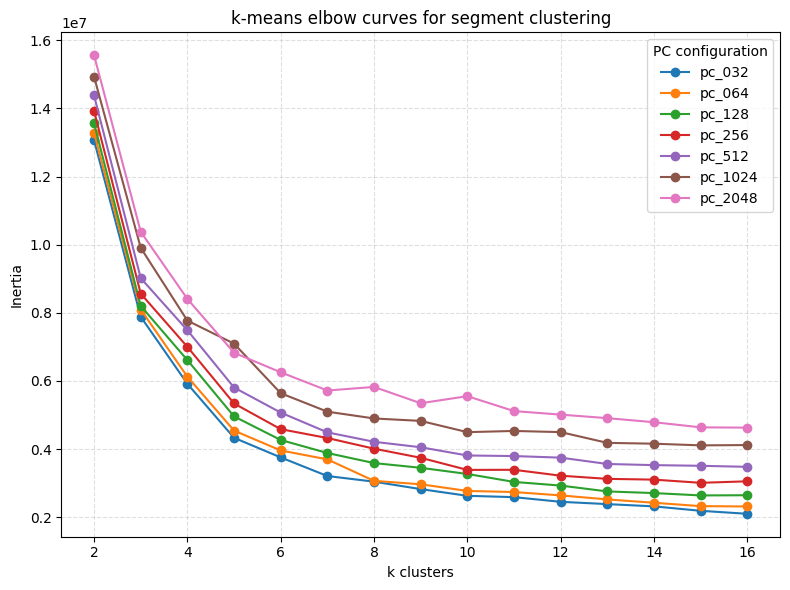

In [13]:
BASE_DIR = Path(data_path)

def pc_sort_key(d: Path) -> int:
    """Extract the PC number from a directory name like 'pc_01'."""
    return int(d.name.split("_")[1])

# Find all pc_* directories.
pc_dirs = sorted(
    (d for d in BASE_DIR.iterdir() if d.is_dir() and d.name.startswith("pc_")),
    key=pc_sort_key
)

print("PC dirs found:", [d.name for d in pc_dirs])

plt.figure(figsize=(8, 6))

for i, pc_dir in enumerate(pc_dirs):
    if i >= 7:
        print("Skipping extra pc_dir:", pc_dir.name)
        continue
    summary_path = pc_dir / "kmeans_summary.npz"
    data = np.load(summary_path)

    k_values = data["k_values"]
    inertias = data["inertias"]

    plt.plot(
        k_values,
        inertias,
        marker="o",
        label=pc_dir.name,
    )

plt.xlabel("k clusters")
plt.ylabel("Inertia")
plt.title("k-means elbow curves for segment clustering")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="PC configuration")
plt.tight_layout()
plt.show()